# 📊 Sales Performance Analysis — Exploratory Data Analysis
### Superstore Sales Dataset
**Tools:** Python · Pandas · Matplotlib · Seaborn  

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Data Quality Check](#3)
4. [Revenue & Profit Distribution](#4)
5. [Monthly Sales Trend](#5)
6. [Category & Sub-Category Analysis](#6)
7. [Customer Segment Analysis](#7)
8. [Regional Performance](#8)
9. [Discount vs Profit Analysis](#9)
10. [Correlation Heatmap](#10)
11. [Key Insights Summary](#11)


## 1. Setup & Data Loading <a id='1'></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (11, 5)})

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [3]:
# Load dataset
df = pd.read_csv("../data/superstore_sales.csv", encoding="latin-1")

# Parse dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"]  = pd.to_datetime(df["Ship Date"])

# Derived columns
df["Year"]          = df["Order Date"].dt.year
df["Month"]         = df["Order Date"].dt.month
df["Month_Name"]    = df["Order Date"].dt.strftime("%b")
df["YearMonth"]     = df["Order Date"].dt.to_period("M").astype(str)
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

✅ Dataset loaded: 9,994 rows × 26 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month_Name,YearMonth,Profit_Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,Nov,2016-11,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,Nov,2016-11,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,Jun,2016-06,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,Oct,2015-10,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,Oct,2015-10,11.25


## 2. Dataset Overview <a id='2'></a>

In [4]:
print("Shape          :", df.shape)
print("Date Range     :", df["Order Date"].min().date(), "→", df["Order Date"].max().date())
print("Unique Orders  :", df["Order ID"].nunique())
print("Unique Customers:", df["Customer ID"].nunique())
print()
print("Categories :", df["Category"].unique().tolist())
print("Regions    :", df["Region"].unique().tolist())
print("Segments   :", df["Segment"].unique().tolist())
print("Ship Modes :", df["Ship Mode"].unique().tolist())

Shape          : (9994, 26)
Date Range     : 2014-01-03 → 2017-12-30
Unique Orders  : 5009
Unique Customers: 793

Categories : ['Furniture', 'Office Supplies', 'Technology']
Regions    : ['South', 'West', 'Central', 'East']
Segments   : ['Consumer', 'Corporate', 'Home Office']
Ship Modes : ['Second Class', 'Standard Class', 'First Class', 'Same Day']


In [5]:
# Key business metrics
metrics = {
    "Total Sales ($)"   : round(df["Sales"].sum(), 2),
    "Total Profit ($)"  : round(df["Profit"].sum(), 2),
    "Profit Margin (%)" : round((df["Profit"].sum() / df["Sales"].sum()) * 100, 2),
    "Total Units Sold"  : int(df["Quantity"].sum()),
    "Avg Discount (%)"  : round(df["Discount"].mean() * 100, 2),
    "Total Orders"      : df["Order ID"].nunique(),
}
for k, v in metrics.items():
    print(f"  {k:<22}: {v:>12,}")

  Total Sales ($)       : 2,297,200.86
  Total Profit ($)      :   286,397.02
  Profit Margin (%)     :        12.47
  Total Units Sold      :       37,873
  Avg Discount (%)      :        15.62
  Total Orders          :        5,009


In [6]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Year                      int32
Month                     int32
Month_Name               object
YearMonth                object
Profit_Margin           float64
dtype: object

## 3. Data Quality Check <a id='3'></a>

In [7]:
# Null values
null_counts = df.isnull().sum()
print("── Null Values ──────────────────────")
print(null_counts[null_counts > 0].to_string() if null_counts.sum() > 0 else "No null values found ✓")

── Null Values ──────────────────────
No null values found ✓


In [8]:
# Duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# Negative sales (should not exist)
neg_sales = df[df["Sales"] <= 0]
print(f"Rows with Sales ≤ 0: {len(neg_sales)}")

# Loss-making transactions
loss = df[df["Profit"] < 0]
print(f"Loss-making transactions: {len(loss)} ({round(len(loss)/len(df)*100, 1)}% of orders)")

Duplicate rows: 0
Rows with Sales ≤ 0: 0
Loss-making transactions: 1871 (18.7% of orders)


In [9]:
# Statistical summary
df[["Sales", "Quantity", "Discount", "Profit", "Profit_Margin"]].describe().round(2)

,Sales,Quantity,Discount,Profit,Profit_Margin
count,9994.00,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66,12.03
std,623.25,2.23,0.21,234.26,46.68
min,0.44,1.00,0.00,-6599.98,-275.00
25%,17.28,2.00,0.00,1.73,7.50
50%,54.49,3.00,0.20,8.67,27.00
75%,209.94,5.00,0.20,29.36,36.25
max,22638.48,14.00,0.80,8399.98,50.00


## 4. Revenue & Profit Distribution <a id='4'></a>

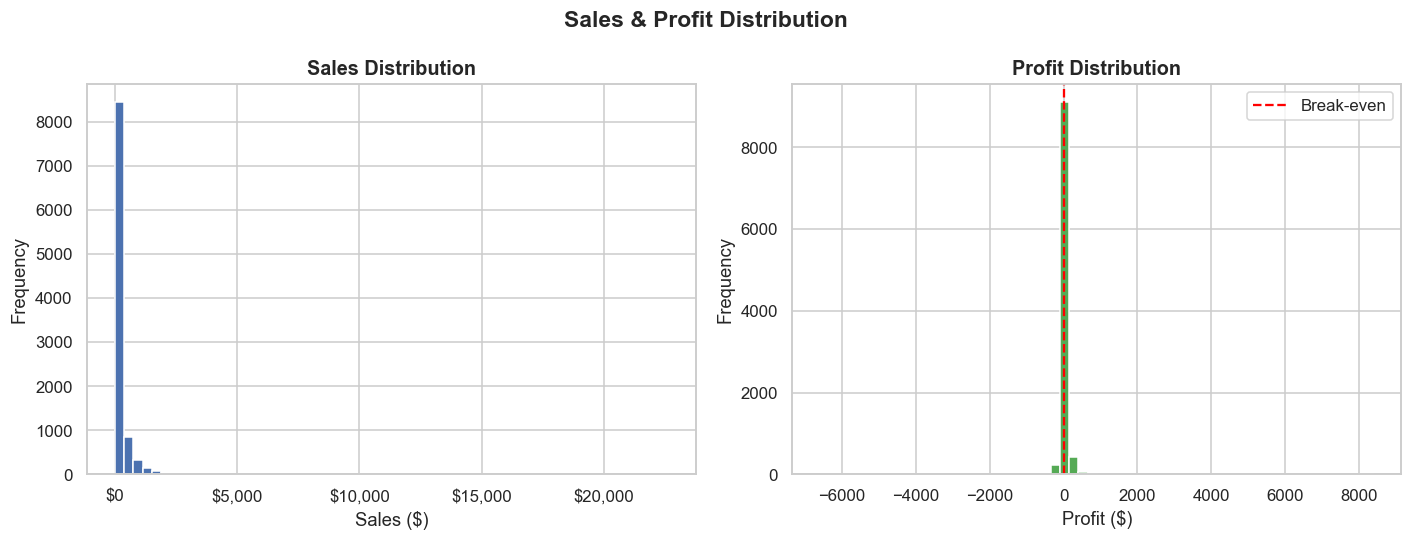

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df["Sales"], bins=60, color="#4C72B0", edgecolor="white")
axes[0].set_title("Sales Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sales ($)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

axes[1].hist(df["Profit"], bins=60, color="#55AA55", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Break-even")
axes[1].set_title("Profit Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Profit ($)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.suptitle("Sales & Profit Distribution", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/01_distribution.png", bbox_inches="tight")
plt.show()

## 5. Monthly Sales Trend <a id='5'></a>

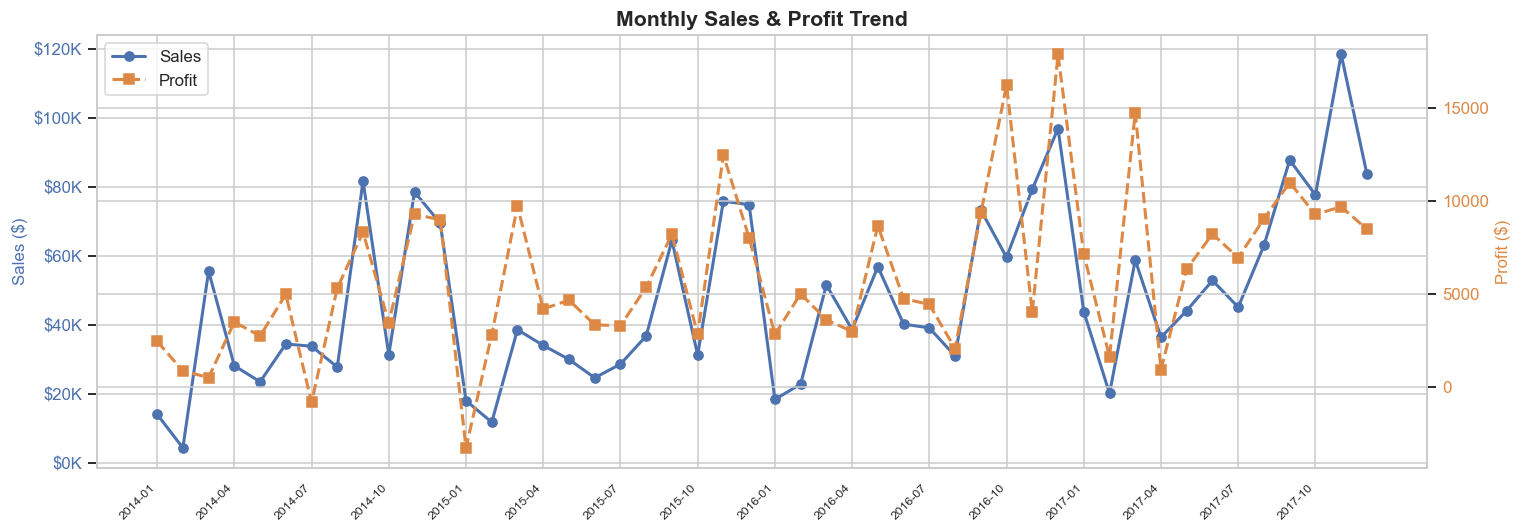

In [11]:
monthly = (
    df.groupby("YearMonth")[["Sales", "Profit"]]
    .sum()
    .reset_index()
    .sort_values("YearMonth")
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly["YearMonth"], monthly["Sales"],  color="#4C72B0", marker="o", lw=2, label="Sales")
ax1.set_ylabel("Sales ($)", color="#4C72B0", fontsize=11)
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))

ax2 = ax1.twinx()
ax2.plot(monthly["YearMonth"], monthly["Profit"], color="#DD8844", marker="s", lw=2, ls="--", label="Profit")
ax2.set_ylabel("Profit ($)", color="#DD8844", fontsize=11)
ax2.tick_params(axis="y", labelcolor="#DD8844")

tick_idx = range(0, len(monthly), 3)
ax1.set_xticks(list(tick_idx))
ax1.set_xticklabels([monthly["YearMonth"].iloc[i] for i in tick_idx], rotation=45, ha="right", fontsize=8)
ax1.set_title("Monthly Sales & Profit Trend", fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("../docs/02_monthly_trend.png", bbox_inches="tight")
plt.show()

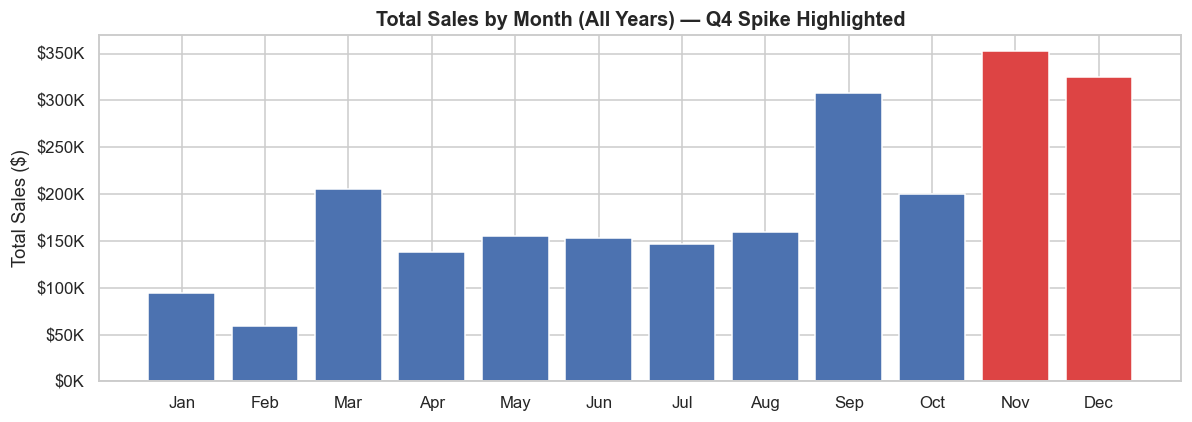

In [12]:
# Q4 effect — average monthly sales by month number
monthly_avg = df.groupby("Month")["Sales"].sum().reset_index()
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
monthly_avg["Month_Name"] = monthly_avg["Month"].map(month_map)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(monthly_avg["Month_Name"], monthly_avg["Sales"],
              color=["#DD4444" if m in [11,12] else "#4C72B0" for m in monthly_avg["Month"]],
              edgecolor="white")
ax.set_title("Total Sales by Month (All Years) — Q4 Spike Highlighted", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
plt.tight_layout()
plt.savefig("../docs/03_monthly_bar.png", bbox_inches="tight")
plt.show()

## 6. Category & Sub-Category Analysis <a id='6'></a>

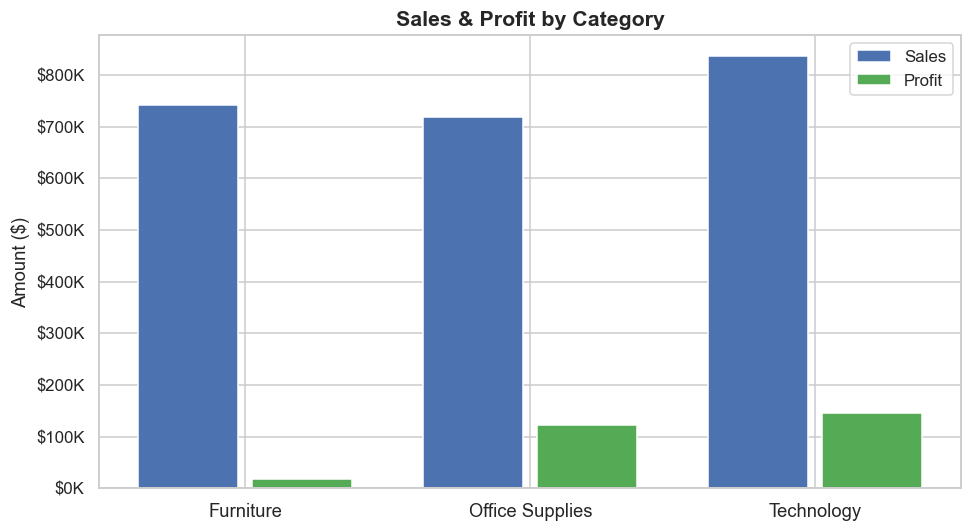

In [13]:
# Category comparison
cat = df.groupby("Category")[["Sales", "Profit"]].sum().reset_index()
x = np.arange(len(cat))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, cat["Sales"],  0.35, label="Sales",  color="#4C72B0")
ax.bar(x + 0.2, cat["Profit"], 0.35, label="Profit", color="#55AA55")
ax.set_xticks(x)
ax.set_xticklabels(cat["Category"], fontsize=12)
ax.set_title("Sales & Profit by Category", fontsize=14, fontweight="bold")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.legend()
plt.tight_layout()
plt.savefig("../docs/04_category.png", bbox_inches="tight")
plt.show()

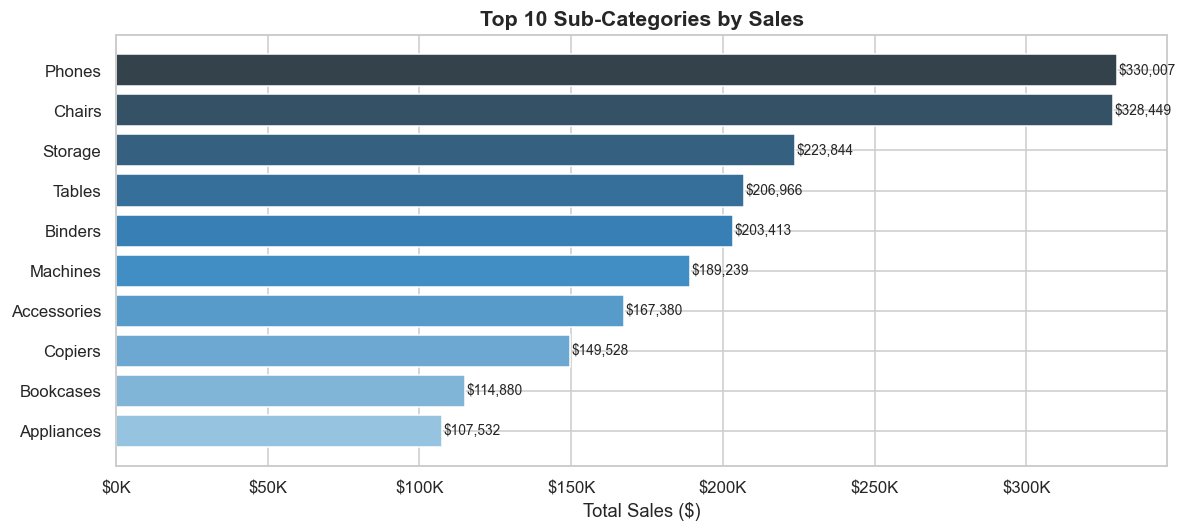

In [14]:
# Top 10 sub-categories by sales
sub = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(sub.index[::-1], sub.values[::-1],
               color=sns.color_palette("Blues_d", 10), edgecolor="white")
for bar, val in zip(bars, sub.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}", va="center", fontsize=9)
ax.set_title("Top 10 Sub-Categories by Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
plt.tight_layout()
plt.savefig("../docs/05_subcategories.png", bbox_inches="tight")
plt.show()

In [15]:
# Sub-categories with negative profit
sub_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
loss_subs  = sub_profit[sub_profit < 0]

print("Sub-categories with NEGATIVE profit:")
for name, val in loss_subs.items():
    print(f"  {name:<20}: ${val:,.2f}")

Sub-categories with NEGATIVE profit:
  Tables              : $-17,725.48
  Bookcases           : $-3,472.56
  Supplies            : $-1,189.10


## 7. Customer Segment Analysis <a id='7'></a>

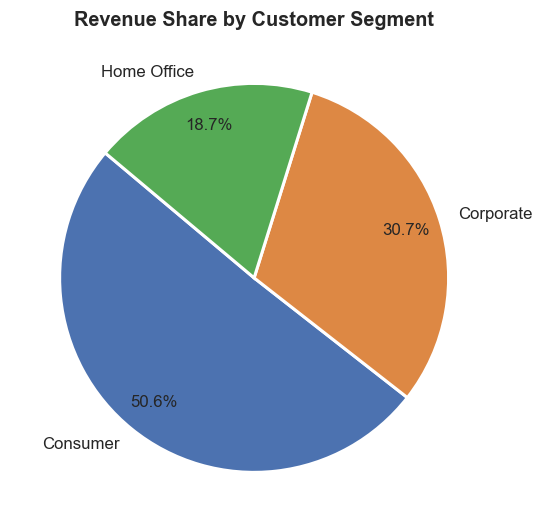

In [16]:
seg = df.groupby("Segment")["Sales"].sum().reset_index().sort_values("Sales", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#4C72B0", "#DD8844", "#55AA55"]
wedges, texts, autotexts = ax.pie(
    seg["Sales"], labels=seg["Segment"], autopct="%1.1f%%",
    colors=colors, startangle=140, pctdistance=0.82,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title("Revenue Share by Customer Segment", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/06_segment.png", bbox_inches="tight")
plt.show()

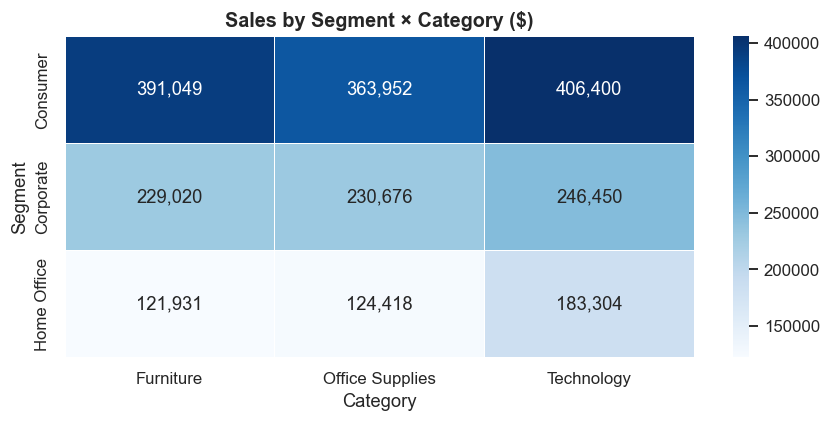

In [17]:
# Segment × Category heatmap
seg_cat = df.groupby(["Segment","Category"])["Sales"].sum().unstack()

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(seg_cat, annot=True, fmt=",.0f", cmap="Blues", linewidths=0.5, ax=ax)
ax.set_title("Sales by Segment × Category ($)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/07_segment_category.png", bbox_inches="tight")
plt.show()

## 8. Regional Performance <a id='8'></a>

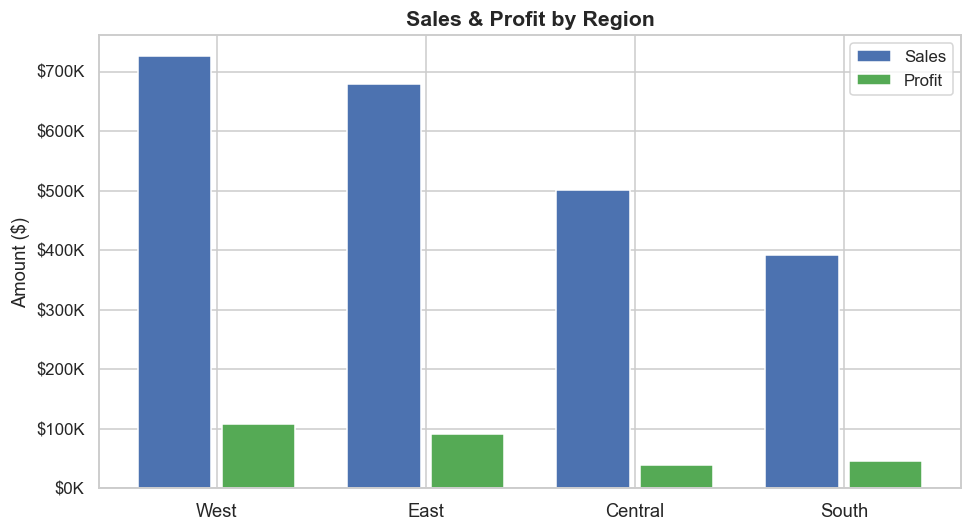

In [18]:
region = df.groupby("Region")[["Sales","Profit"]].sum().reset_index().sort_values("Sales", ascending=False)

x = np.arange(len(region))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, region["Sales"],  0.35, label="Sales",  color="#4C72B0")
ax.bar(x + 0.2, region["Profit"], 0.35, label="Profit", color="#55AA55")
ax.set_xticks(x)
ax.set_xticklabels(region["Region"], fontsize=12)
ax.set_title("Sales & Profit by Region", fontsize=14, fontweight="bold")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.legend()
plt.tight_layout()
plt.savefig("../docs/08_region.png", bbox_inches="tight")
plt.show()

## 9. Discount vs Profit Analysis <a id='9'></a>

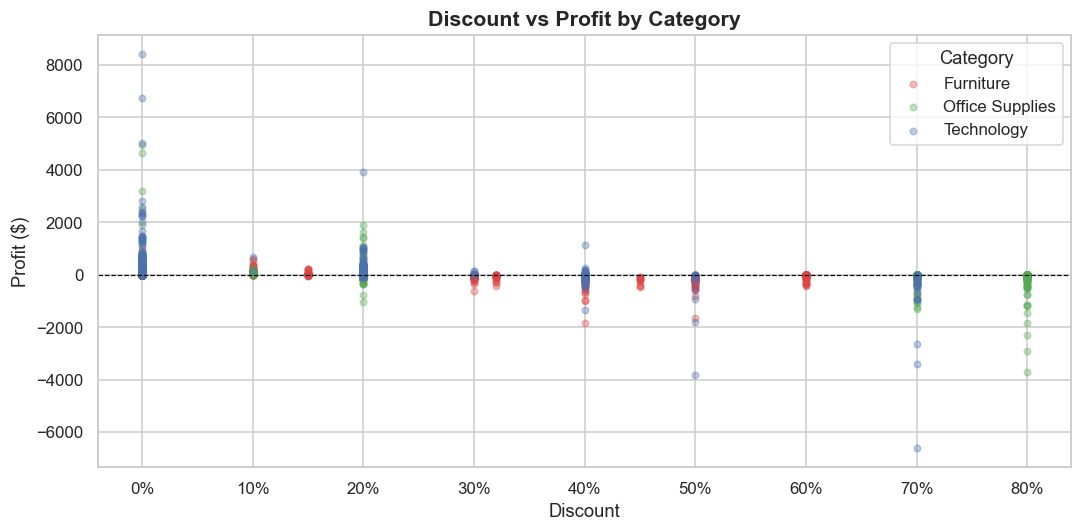

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
palette = {"Technology": "#4C72B0", "Office Supplies": "#55AA55", "Furniture": "#DD4444"}
for cat_name, grp in df.groupby("Category"):
    ax.scatter(grp["Discount"], grp["Profit"], alpha=0.35, s=18,
               label=cat_name, color=palette[cat_name])
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Discount vs Profit by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit ($)")
ax.legend(title="Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
plt.tight_layout()
plt.savefig("../docs/09_discount_profit.png", bbox_inches="tight")
plt.show()

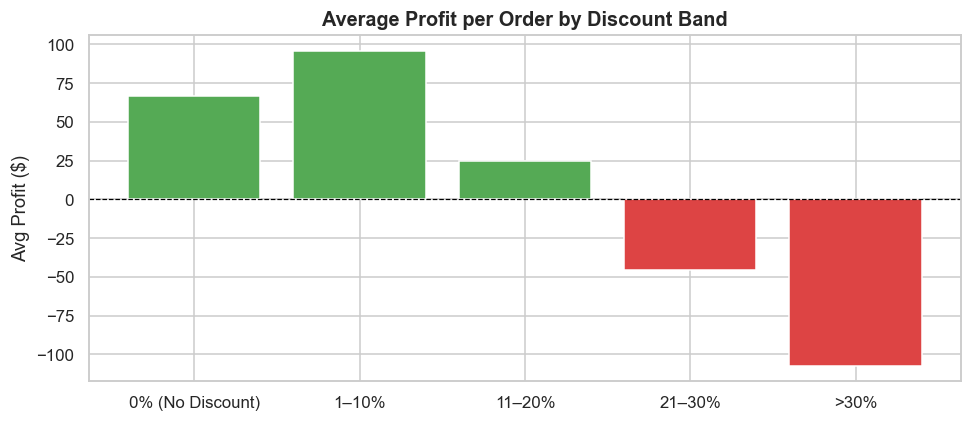

In [20]:
# Discount bands vs average profit
def discount_band(d):
    if d == 0:      return "0% (No Discount)"
    elif d <= 0.10: return "1–10%"
    elif d <= 0.20: return "11–20%"
    elif d <= 0.30: return "21–30%"
    else:           return ">30%"

df["Discount_Band"] = df["Discount"].apply(discount_band)
band_order = ["0% (No Discount)", "1–10%", "11–20%", "21–30%", ">30%"]

band_profit = df.groupby("Discount_Band")["Profit"].mean().reindex(band_order)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#55AA55" if v > 0 else "#DD4444" for v in band_profit.values]
ax.bar(band_profit.index, band_profit.values, color=colors, edgecolor="white")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_title("Average Profit per Order by Discount Band", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Profit ($)")
plt.tight_layout()
plt.savefig("../docs/10_discount_bands.png", bbox_inches="tight")
plt.show()

## 10. Correlation Heatmap <a id='10'></a>

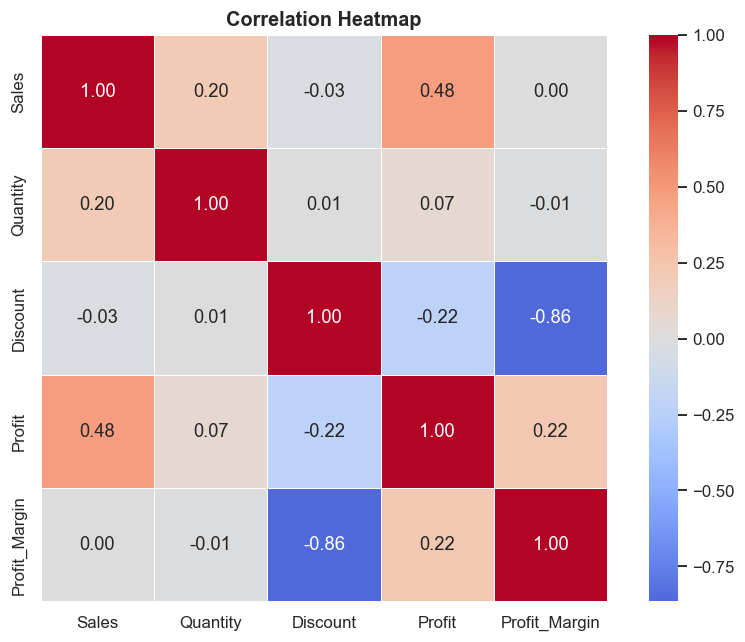

In [21]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Profit_Margin"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, square=True)
ax.set_title("Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/11_correlation.png", bbox_inches="tight")
plt.show()

## 11. Key Insights Summary <a id='11'></a>

| # | Insight |
|---|---|
| 1 | **Technology** is the top category by both revenue and profit |
| 2 | **Tables & Bookcases** consistently generate negative profit — high discount risk |
| 3 | **Q4 (Nov–Dec)** sees the highest sales spike across all years |
| 4 | **Consumer segment** drives ~50% of total revenue |
| 5 | **West region** leads in sales; **South** has the highest avg discount |
| 6 | Discounts above **30%** almost always result in a loss |
| 7 | **Discount and Profit** are negatively correlated (r ≈ −0.22) |
| 8 | **Copiers** sub-category has the highest profit margin despite low volume |

---
*Analysis by Kavish Rathod | Superstore Sales Dataset*
